In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
import pickle
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/molecular-biology/promoter-gene-sequences/promoters.data'
names = ['Class', 'id', 'Sequence']
data = pd.read_csv(url, names = names)

In [2]:
data.head(10)

,Class,id,Sequence
0,+,S10,\t\ttactagcaatacgcttgcgttcggtggttaagtatgtataat...
1,+,AMPC,\t\ttgctatcctgacagttgtcacgctgattggtgtcgttacaat...
2,+,AROH,\t\tgtactagagaactagtgcattagcttatttttttgttatcat...
3,+,DEOP2,\taattgtgatgtgtatcgaagtgtgttgcggagtagatgttagaa...
4,+,LEU1_TRNA,\ttcgataattaactattgacgaaaagctgaaaaccactagaatgc...
5,+,MALEFG,\taggggcaaggaggatggaaagaggttgccgtataaagaaactag...
6,+,MALK,\t\tcagggggtggaggatttaagccatctcctgatgacgcatagt...
7,+,RECA,\t\ttttctacaaaacacttgatactgtatgagcatacagtataat...
8,+,RPOB,\t\tcgacttaatatactgcgacaggacgtccgttctgtgtaaatc...
9,+,RRNAB_P1,\tttttaaatttcctcttgtcaggccggaataactccctataatgc...


In [3]:
data.shape

(106, 3)

In [4]:
data.dtypes

Class       object
id          object
Sequence    object
dtype: object

In [5]:
# Refining and structuring the data

# Build our dataset using custom pandas dataframe
classes = data.loc[:,'Class']
classes.head()
print()
print(classes.value_counts())


Class
+    53
-    53
Name: count, dtype: int64


In [6]:
# generate list of DNA sequence
sequence = list(data.loc[:, 'Sequence'])
sequence[-1]

'\t\ttaacattaataaataaggaggctctaatggcactcattagccaatcaatcaagaact'

In [7]:
#Remove tab from each sequence
dic = {}
for i, seq in enumerate(sequence):
    nucleotides = list(seq)
    nucleotides = [char for char in nucleotides if char != '\t']
    #append class assignment
    nucleotides.append(classes[i])
    
    dic[i] = nucleotides
list(dic[0])

['t',
 'a',
 'c',
 't',
 'a',
 'g',
 'c',
 'a',
 'a',
 't',
 'a',
 'c',
 'g',
 'c',
 't',
 't',
 'g',
 'c',
 'g',
 't',
 't',
 'c',
 'g',
 'g',
 't',
 'g',
 'g',
 't',
 't',
 'a',
 'a',
 'g',
 't',
 'a',
 't',
 'g',
 't',
 'a',
 't',
 'a',
 'a',
 't',
 'g',
 'c',
 'g',
 'c',
 'g',
 'g',
 'g',
 'c',
 't',
 't',
 'g',
 't',
 'c',
 'g',
 't',
 '+']

In [8]:
# Convert Dict object into dataframe
df = pd.DataFrame(dic)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,96,97,98,99,100,101,102,103,104,105
0,t,t,g,a,t,a,c,t,c,t,...,c,c,t,a,g,c,g,c,c,t
1,a,g,t,a,c,g,a,t,g,t,...,c,g,a,g,a,c,t,g,t,a
2,c,c,a,t,g,g,g,t,a,t,...,g,c,t,a,g,t,a,c,c,a
3,t,t,c,t,a,g,g,c,c,t,...,a,t,g,g,a,c,t,g,g,c
4,a,a,t,g,t,g,g,t,t,a,...,g,a,a,g,g,a,t,a,t,a


In [9]:
# transpose dataframe into correct format
df = df.transpose()
df.head()

,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,57
0,t,a,c,t,a,g,c,a,a,t,...,g,c,t,t,g,t,c,g,t,+
1,t,g,c,t,a,t,c,c,t,g,...,c,a,t,c,g,c,c,a,a,+
2,g,t,a,c,t,a,g,a,g,a,...,c,a,c,c,c,g,g,c,g,+
3,a,a,t,t,g,t,g,a,t,g,...,a,a,c,a,a,a,c,t,c,+
4,t,c,g,a,t,a,a,t,t,a,...,c,c,g,t,g,g,t,a,g,+


In [10]:
# Rename the 57th column as it is our classes
df.rename(columns = {57:'Class'}, inplace = True)

In [11]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,Class
0,t,a,c,t,a,g,c,a,a,t,...,g,c,t,t,g,t,c,g,t,+
1,t,g,c,t,a,t,c,c,t,g,...,c,a,t,c,g,c,c,a,a,+
2,g,t,a,c,t,a,g,a,g,a,...,c,a,c,c,c,g,g,c,g,+
3,a,a,t,t,g,t,g,a,t,g,...,a,a,c,a,a,a,c,t,c,+
4,t,c,g,a,t,a,a,t,t,a,...,c,c,g,t,g,g,t,a,g,+


In [12]:
temp = df.copy(deep=True)
temp = temp.drop(['Class'], axis = 1)

temp.head()

,0,1,2,3,4,5,6,7,8,9,...,47,48,49,50,51,52,53,54,55,56
0,t,a,c,t,a,g,c,a,a,t,...,g,g,c,t,t,g,t,c,g,t
1,t,g,c,t,a,t,c,c,t,g,...,g,c,a,t,c,g,c,c,a,a
2,g,t,a,c,t,a,g,a,g,a,...,c,c,a,c,c,c,g,g,c,g
3,a,a,t,t,g,t,g,a,t,g,...,t,a,a,c,a,a,a,c,t,c
4,t,c,g,a,t,a,a,t,t,a,...,t,c,c,g,t,g,g,t,a,g


In [13]:
# Encoding using one-hot encoder:

enc = OneHotEncoder(handle_unknown='ignore')
enc.fit(temp)
print(enc.categories_)
df1 = enc.transform(temp).toarray()
del temp
# df1[1:3]

[array(['a', 'c', 'g', 't'], dtype=object), array(['a', 'c', 'g', 't'], dtype=object), array(['a', 'c', 'g', 't'], dtype=object), array(['a', 'c', 'g', 't'], dtype=object), array(['a', 'c', 'g', 't'], dtype=object), array(['a', 'c', 'g', 't'], dtype=object), array(['a', 'c', 'g', 't'], dtype=object), array(['a', 'c', 'g', 't'], dtype=object), array(['a', 'c', 'g', 't'], dtype=object), array(['a', 'c', 'g', 't'], dtype=object), array(['a', 'c', 'g', 't'], dtype=object), array(['a', 'c', 'g', 't'], dtype=object), array(['a', 'c', 'g', 't'], dtype=object), array(['a', 'c', 'g', 't'], dtype=object), array(['a', 'c', 'g', 't'], dtype=object), array(['a', 'c', 'g', 't'], dtype=object), array(['a', 'c', 'g', 't'], dtype=object), array(['a', 'c', 'g', 't'], dtype=object), array(['a', 'c', 'g', 't'], dtype=object), array(['a', 'c', 'g', 't'], dtype=object), array(['a', 'c', 'g', 't'], dtype=object), array(['a', 'c', 'g', 't'], dtype=object), array(['a', 'c', 'g', 't'], dtype=object), array(['a'

In [16]:
import os, pickle

# ensure the folder exists
out_path = r"d:\project_learning\Nlp-2\Dna classification\EColi-encoder.pickle"
os.makedirs(os.path.dirname(out_path), exist_ok=True)

# save the encoder
with open(out_path, "wb") as f:
    pickle.dump(enc, f)

# later you can load it with
# with open(out_path, "rb") as f:
#     encoder = pickle.load(f)
# data = encoder.transform(df).toarray()


In [19]:
df_new = pd.DataFrame(df1)
df_new.head()

,0,1,2,3,4,5,6,7,8,9,...,218,219,220,221,222,223,224,225,226,227
0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [20]:
df["Class"] = df["Class"].replace({"+": 1, "-": 0})
df_new = df.copy()
df_new["Classes"] = df_new["Class"]
df_new.head()


,0,1,2,3,4,5,6,7,8,9,...,49,50,51,52,53,54,55,56,Class,Classes
0,t,a,c,t,a,g,c,a,a,t,...,c,t,t,g,t,c,g,t,1,1
1,t,g,c,t,a,t,c,c,t,g,...,a,t,c,g,c,c,a,a,1,1
2,g,t,a,c,t,a,g,a,g,a,...,a,c,c,c,g,g,c,g,1,1
3,a,a,t,t,g,t,g,a,t,g,...,a,c,a,a,a,c,t,c,1,1
4,t,c,g,a,t,a,a,t,t,a,...,c,g,t,g,g,t,a,g,1,1


In [21]:
#Encoding - Alternative
numerical_df = pd.get_dummies(df)
numerical_df.head()

,Class,0_a,0_c,0_g,0_t,1_a,1_c,1_g,1_t,2_a,...,54_g,54_t,55_a,55_c,55_g,55_t,56_a,56_c,56_g,56_t
0,1,False,False,False,True,True,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
1,1,False,False,False,True,False,False,True,False,False,...,False,False,True,False,False,False,True,False,False,False
2,1,False,False,True,False,False,False,False,True,True,...,True,False,False,True,False,False,False,False,True,False
3,1,True,False,False,False,True,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
4,1,False,False,False,True,False,True,False,False,False,...,False,True,True,False,False,False,False,False,True,False


In [22]:
# Training and Testing the Classification Algorithms

In [23]:
y = df_new['Classes'].values# numerical_df['Class'].values
X = df_new.drop(['Classes'], axis = 1).values# numerical_df.drop(['Class'], axis = 1).values

#define a seed for reproducibility
seed = 1

# Splitting data into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = seed)

In [31]:
import os, pickle, pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/molecular-biology/promoter-gene-sequences/promoters.data'
df = pd.read_csv(url, names=['Class', 'id', 'Sequence'])
y = df['Class'].map({'+': 1, '-': 0}).values

max_len = df['Sequence'].str.len().max()
seq_arr = np.array([list(s.ljust(max_len, 'N')) for s in df['Sequence']])
enc = OneHotEncoder(sparse=False, dtype=int)
X = enc.fit_transform(seq_arr)

enc_path = os.path.join('d:/project_learning/Nlp-2/Dna classification', 'EColi-encoder.pickle')
with open(enc_path, 'wb') as f:
    pickle.dump(enc, f)

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

mlp = MLPClassifier(hidden_layer_sizes=(150,100,50), max_iter=300,
                    activation='relu', solver='adam', random_state=1)
mlp.fit(X_tr, y_tr)

pred = mlp.predict(X_te)
print('Acc:', accuracy_score(y_te, pred))
print('Report:\n', classification_report(y_te, pred))
print('CM:\n', confusion_matrix(y_te, pred))


c:\Users\dell\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


Acc: 0.8181818181818182
Report:
               precision    recall  f1-score   support

           0       0.82      0.82      0.82        11
           1       0.82      0.82      0.82        11

    accuracy                           0.82        22
   macro avg       0.82      0.82      0.82        22
weighted avg       0.82      0.82      0.82        22

CM:
 [[9 2]
 [2 9]]


In [34]:
# ----- 1️⃣ Load & encode -------------------------------------------------
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/molecular-biology/promoter-gene-sequences/promoters.data'
df = pd.read_csv(url, names=['Class', 'id', 'Sequence'])
y = df['Class'].map({'+': 1, '-': 0}).values

max_len = df['Sequence'].str.len().max()
seq_arr = np.array([list(s.ljust(max_len, 'N')) for s in df['Sequence']])
enc = OneHotEncoder(sparse=False, dtype=int)
X = enc.fit_transform(seq_arr)          # numeric matrix ready for sklearn

# ----- 2️⃣ Train‑test split (keep encoded X) ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# ----- 3️⃣ Model ---------------------------------------------------------
mlp = MLPClassifier(hidden_layer_sizes=(150,100,50),
                     max_iter=300, activation='relu',
                     solver='adam', random_state=1)
mlp.fit(X_train, y_train)

# ----- 4️⃣ Predict & evaluate (now X_test is numeric) --------------------
y_pred = mlp.predict(X_test)
print('Accuracy :', mlp.score(X_test, y_test))   # same as accuracy_score(y_test, y_pred)


c:\Users\dell\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


Accuracy : 0.8181818181818182


In [35]:
# Model evaluation
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.82      0.82        11
           1       0.82      0.82      0.82        11

    accuracy                           0.82        22
   macro avg       0.82      0.82      0.82        22
weighted avg       0.82      0.82      0.82        22



<Axes: >

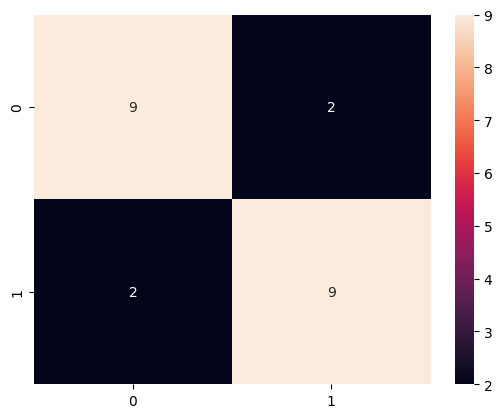

In [36]:
#Importing Confusion Matrix
#Comparing the predictions against the actual observations in y_val
cm = confusion_matrix(y_pred, y_test)
sns.heatmap(cm, annot=True)

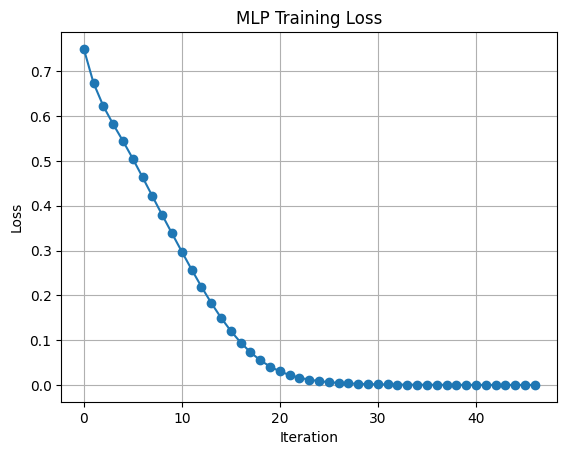

In [38]:
import matplotlib.pyplot as plt

# after mlp.fit(...)
plt.plot(mlp.loss_curve_, marker='o')
plt.title('MLP Training Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.grid(True)
plt.show()


In [40]:
import os, pickle

# make sure you use the trained MLP instance (named mlp in the notebook)
model = mlp

# build a safe absolute path – the folder already exists
out_path = os.path.join(
    r'd:/project_learning/Nlp-2/Dna classification',
    'E-Coli_model.pickle'
)

# dump the model
with open(out_path, 'wb') as f:
    pickle.dump(model, f)

print(f'Model saved to: {out_path}')


Model saved to: d:/project_learning/Nlp-2/Dna classification\E-Coli_model.pickle


In [41]:
genome = "ttactagcaatacgcttgcgttcggtggttaagtatgtataatgcgcgggcttgtcg"
# genome_false = "ttaacattaataaataaggaggctctaatggcactcattagccaatcaatcaagaac"
genome_list = list(genome)
print(genome_list)
df_test = pd.DataFrame(genome_list)
df_test = df_test.transpose()

['t', 't', 'a', 'c', 't', 'a', 'g', 'c', 'a', 'a', 't', 'a', 'c', 'g', 'c', 't', 't', 'g', 'c', 'g', 't', 't', 'c', 'g', 'g', 't', 'g', 'g', 't', 't', 'a', 'a', 'g', 't', 'a', 't', 'g', 't', 'a', 't', 'a', 'a', 't', 'g', 'c', 'g', 'c', 'g', 'g', 'g', 'c', 't', 't', 'g', 't', 'c', 'g']


In [42]:
df.head()

,Class,id,Sequence
0,+,S10,\t\ttactagcaatacgcttgcgttcggtggttaagtatgtataat...
1,+,AMPC,\t\ttgctatcctgacagttgtcacgctgattggtgtcgttacaat...
2,+,AROH,\t\tgtactagagaactagtgcattagcttatttttttgttatcat...
3,+,DEOP2,\taattgtgatgtgtatcgaagtgtgttgcggagtagatgttagaa...
4,+,LEU1_TRNA,\ttcgataattaactattgacgaaaagctgaaaaccactagaatgc...


In [ ]:

pred = model.predict(X_test)

print(pred)               # e.g. [0 1 0 …]
print(type(pred[0]))      # <class 'numpy.int64'>


[1 1 0 1 1 0 0 0 1 1 0 1 1 0 1 0 0 0 0 1 0 1]
<class 'numpy.int64'>
